# Accelerated DICOM Decoding with nvImageCodec and pydicom

This notebook introduces how to use the nvImageCodec pydicom plugin for GPU-accelerated DICOM decoding.

The **pydicom plugin** is the easiest way to get GPU-accelerated DICOM decoding with nvImageCodec. This plugin integrates seamlessly with pydicom's standard workflow - you just register it once, and then use pydicom normally. The plugin automatically accelerates decoding for supported transfer syntaxes when you access `.pixel_array`.

### Supported Transfer Syntaxes

The nvImageCodec pydicom plugin supports the following compressed transfer syntaxes:
- **JPEG Baseline (Process 1)** - `1.2.840.10008.1.2.4.50`
- **JPEG Lossless** - `1.2.840.10008.1.2.4.57` & `1.2.840.10008.1.2.4.70`
- **JPEG 2000** - `1.2.840.10008.1.2.4.90` & `1.2.840.10008.1.2.4.91`
- **HTJ2K (High-Throughput JPEG 2000)** - `1.2.840.10008.1.2.4.201`, `1.2.840.10008.1.2.4.202`, `1.2.840.10008.1.2.4.203`

### How to Use

It's just three simple steps:

1. **Import and register** the plugin
2. **Load DICOM** files with `pydicom.dcmread()`
3. **Access pixel data** with `.pixel_array` - GPU acceleration happens automatically!
4. **Unregister** (optionally) to stop using the plugin

Let's see an example:

In [1]:
import pydicom
from pydicom.data import get_testdata_file

# Use a JPEG 2000 test file that is bundled with pydicom
test_file = get_testdata_file("emri_small_jpeg_2k_lossless.dcm")
if test_file is None:
    raise FileNotFoundError("No JPEG 2000 test file found. Install pydicom with test data or provide your own DICOM path.")
ds = pydicom.dcmread(test_file, stop_before_pixels=True)
print("Transfer syntax:", ds.file_meta.TransferSyntaxUID)

from pydicom.pixels.decoders import JPEG2000Decoder
print(JPEG2000Decoder._available)

Transfer syntax: 1.2.840.10008.1.2.4.90
{'pylibjpeg': <function _decode_frame at 0x7667f8ff7eb0>, 'pillow': <function _decode_frame at 0x7667f654d240>}


We can see that pydicom has two plugins "pillow" and "pylibjpeg" that can decode JPEG2000 format. We can now register our nvImageCodec plugin to be the first choice:

In [2]:
from nvidia.nvimgcodec.tools.dicom import pydicom_plugin
pydicom_plugin.register()
print(JPEG2000Decoder._available)

{'0.8.0+nvimgcodec': <function _decode_frame at 0x76678ed87910>, 'pillow': <function _decode_frame at 0x7667f654d240>, 'pylibjpeg': <function _decode_frame at 0x7667f8ff7eb0>}


We can even clear the list of available decoders to force our decoder to be the only choice for this format. We will do that in this example to be sure that what we decoded was the output of the nvImageCodec plugin

In [3]:
pydicom_plugin.unregister()
old_decoder_class_available = {}
from nvidia.nvimgcodec.tools.dicom.pydicom_plugin import SUPPORTED_DECODER_CLASSES
for decoder_class in SUPPORTED_DECODER_CLASSES:
    old_decoder_class_available[decoder_class.UID] = decoder_class._available
    decoder_class._available = {}
pydicom_plugin.register()
print(JPEG2000Decoder._available)


{'0.8.0+nvimgcodec': <function _decode_frame at 0x76678ed87910>}


Now we can access to pixel data, which will use accelerated GPU decoding via nvImageCodec:

(10, 64, 64)


Text(0.5, 1.0, 'DICOM Pixel Data (GPU Decoded via nvImageCodec)')

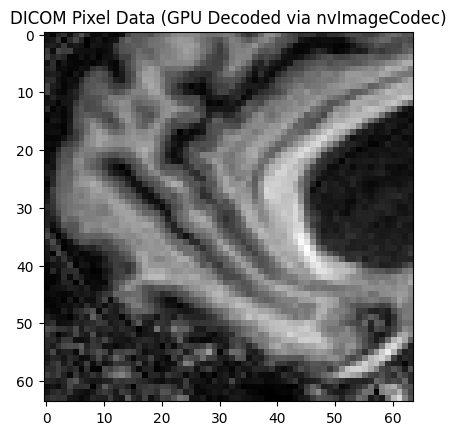

In [ ]:
ds = pydicom.dcmread(test_file)
pixels = ds.pixel_array
print(pixels.shape)
pixels = pixels[0]  # first frame

# Plot the image pixel data
import matplotlib.pyplot as plt
plt.imshow(pixels, cmap="gray")
plt.title("DICOM Pixel Data (GPU Decoded via nvImageCodec)")

Now that the plugin is registered, any time you load a DICOM file with a supported compressed transfer syntax and access `.pixel_array`, nvImageCodec will automatically handle the decoding on the GPU.

## Performance Comparison

Let's compare the performance of the nvImageCodec plugin against the default pydicom decoders. We'll use the performance test from the test suite to benchmark decoding speed across various DICOM files.

In [5]:
# Run performance benchmarks
import sys
import os
from pathlib import Path
import io
from contextlib import redirect_stdout, redirect_stderr

test_dir_root = os.getenv("PYNVIMGCODEC_TEST_DIR", "../../test/python")
test_dir = Path(test_dir_root) / "integration" / "dicom"
if str(test_dir) not in sys.path:
    sys.path.insert(0, str(test_dir))

print("Downloading test DICOM files")
# Silence output from get_test_dicoms
with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
    from pydicom.data  import get_testdata_files
    files = get_testdata_files("*.dcm")

from test_pydicom_plugin import performance_test_nvimgcodec_decoder_against_defaults

for decoder_class in SUPPORTED_DECODER_CLASSES:
    decoder_class._available = old_decoder_class_available[decoder_class.UID]

# Run the performance test with a small number of runs for demo purposes
print("Running performance benchmarks...")
print("This compares CPU-based decoders (baseline) vs GPU-accelerated nvImageCodec plugin\n")

performance_test_nvimgcodec_decoder_against_defaults(
    num_warmup_runs=2,
    num_test_runs=5,
    file_paths=files,
)

Running performance benchmarks...
This compares CPU-based decoders (baseline) vs GPU-accelerated nvImageCodec plugin



/home/janton/.local/lib/python3.10/site-packages/pydicom/filereader.py:487: UserWarning: End of file reached before delimiter (FFFE,E0DD) found in file /home/janton/.pydicom/data/emri_small_jpeg_2k_lossless_too_short.dcm
  warn_and_log(msg, UserWarning)
Error testing emri_small_jpeg_2k_lossless_too_short.dcm: The dataset has no 'Pixel Data', 'Float Pixel Data' or 'Double Float Pixel Data' element, no pixel data to decode
Error testing OT-PAL-8-face.dcm: File is missing DICOM File Meta Information header or the 'DICM' prefix is missing from the header. Use force=True to force reading.
Error testing JLSL_RGB_ILV0.dcm: File is missing DICOM File Meta Information header or the 'DICM' prefix is missing from the header. Use force=True to force reading.
Error testing JLSL_RGB_ILV1.dcm: File is missing DICOM File Meta Information header or the 'DICM' prefix is missing from the header. Use force=True to force reading.
Error testing JLSL_RGB_ILV2.dcm: File is missing DICOM File Meta Information 


## Performance Results (2 warmup, 5 test runs)

| Transfer Syntax | Shape | Baseline (s) | Std | nvimgcodec (s) | Std | Speedup | File |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 1.2.840.10008.1.2.4.90 | 512x512 | 0.0394 | 0.0006 | 0.0180 | 0.0008 | 2.19x | 693_J2KR.dcm |
| 1.2.840.10008.1.2.1 | 512x512 | 0.0018 | 0.0000 | 0.0018 | 0.0000 | 0.98x | 693_UNCI.dcm |
| 1.2.840.10008.1.2.1 | 512x512 | 0.0016 | 0.0000 | 0.0015 | 0.0000 | 1.04x | 693_UNCR.dcm |
| 1.2.840.10008.1.2.4.70 | 512x512 | 0.0251 | 0.0001 | 0.0045 | 0.0001 | 5.59x | bad_sequence.dcm |
| 1.2.840.10008.1.2.1 | 120x256x3 | 0.0015 | 0.0000 | 0.0015 | 0.0000 | 1.00x | color-pl.dcm |
| 1.2.840.10008.1.2.1 | 120x256x3 | 0.0011 | 0.0000 | 0.0011 | 0.0000 | 1.01x | color-px.dcm |
| 1.2.840.10008.1.2.4.50 | 120x480x640x3 | 2.1130 | 0.0057 | 0.3458 | 0.0007 | 6.11x | color3d_jpeg_baseline.dcm |
| 1.2.840.10008.1.2.1 | 2x512x512 | 0.0033 | 0.0000 | 0.0033 | 0.0000 | 1.01x | eCT_Supplemental.dcm |
| 1.2.840.10008.1.2.1 

### Understanding the Results

The performance comparison shows speedup factors for different DICOM files. Key observations:

**For Small Images:**
- GPU decoding may be **slower** than CPU for small images
- This is due to the **overhead** of transferring data between CPU and GPU memory
- The time spent copying data back and forth can exceed the decoding time savings

**For Large Images:**
- GPU decoding becomes **significantly faster** as image size increases
- The parallel processing power of the GPU outweighs the transfer overhead
- Speedups of 2-10x or more are common for larger medical images

**Further Acceleration:**
The pydicom plugin provides easy GPU acceleration with zero code changes. However, for even better performance with multiple slices or large series, see the **Advanced Batch Decoding** section which demonstrates:

- **Batch decoding**: Process multiple DICOM slices simultaneously
- **GPU-only workflows**: Consume decoded data directly on GPU without CPU copies
- **Direct nvImageCodec API**: Fine-grained control for maximum throughput

These advanced techniques can provide additional speedups, especially when processing entire DICOM series or integrating with GPU-based processing pipelines.